# Takens Embedding
## Converting financial time series into point clouds

A 1D return series cannot be directly analyzed by TDA — we need a **point cloud in a metric space**. The Takens embedding theorem provides the theoretical foundation for this conversion.

Given a time series $\{r_t\}$ and an embedding dimension $d$, the sliding window embedding maps each time step to a point in $\mathbb{R}^d$:

$$r_t \mapsto (r_t, r_{t-1}, \ldots, r_{t-d+1}) \in \mathbb{R}^d$$

We use **False Nearest Neighbors (FNN)** to find the optimal embedding dimension $d$ for each asset independently — a data-driven approach that avoids arbitrary parameter choices.

We implement FNN for all three assets independently — S&P 500, TSLA, and BTC-USD — since each asset may have a different optimal $d$ reflecting its underlying market dynamics.

## Takens Embedding Theorem

Let $M$ be the unknown state space of a dynamical system evolving under a map $f: M \to M$. We cannot observe $M$ directly — we only observe a scalar measurement $\phi(x) \in \mathbb{R}$ at each time step.

The **delay embedding** reconstructs the state space from observations alone:

$$\mathbf{x}_t = (r_t, r_{t+1}, \ldots, r_{t+d-1}) \in \mathbb{R}^d$$

**Takens (1981)** proves that if $d \geq 2m + 1$ where $m = \dim(M)$, this reconstruction is topologically equivalent to $M$ — regardless of the unknown dynamics $f$.

The key insight is that $f$ is never needed explicitly — its effect is already encoded in the consecutive observations. Each step $r_t \to r_{t+1}$ is the result of $f$ acting on the system.

**For financial data:** $M$ is the unknown market state space, $r_t$ is the observed log return, and $d$ is what we need to determine. This is the role of **False Nearest Neighbors**.

## False Nearest Neighbors (FNN)

In dimension $d$, two points are **false nearest neighbors** if they appear close together only because the embedding dimension is too low — they are artificially projected onto each other.

As $d$ increases, the attractor unfolds and false neighbors separate. The algorithm:

1. For each point $\mathbf{x}_t \in \mathbb{R}^d$, find its nearest neighbor $\mathbf{x}_{t^*}$
2. Embed both into $\mathbb{R}^{d+1}$ and measure how their distance changes
3. If the distance increases dramatically → they were **false neighbors** in $\mathbb{R}^d$
4. Count the percentage of false neighbors at each $d$
5. The optimal $d$ is where this percentage **drops to zero** (or near zero)

Formally, a neighbor is declared false if:

$$\frac{|r_{t+d} - r_{t^*+d}|}{\|\mathbf{x}_t - \mathbf{x}_{t^*}\|} > R_{tol}$$

where $R_{tol}$ is a threshold (typically 10-15).

We compute FNN once per asset and use the resulting $d$ as a fixed embedding dimension throughout — consistent with Gidea & Katz (2018) and Barrios et al. (2026). Rolling FNN is left as future work.

In [1]:
import sys
sys.path.insert(0, '/home/gabo-linux/TDA-Gabo/tda-financial-data-pipeline')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load preprocessed normalized returns
sp500 = pd.read_csv('../data/processed/sp500_returns_normalized.csv', 
                    index_col=0, parse_dates=True).squeeze()
tsla = pd.read_csv('../data/processed/tsla_returns_normalized.csv', 
                   index_col=0, parse_dates=True).squeeze()
btc = pd.read_csv('../data/processed/btc_returns_normalized.csv', 
                  index_col=0, parse_dates=True).squeeze()

print(f"S&P 500: {len(sp500)} days")
print(f"TSLA:    {len(tsla)} days")
print(f"BTC:     {len(btc)} days")

S&P 500: 6036 days
TSLA:    3399 days
BTC:     3392 days


## False Nearest Neighbors Implementation

We implement FNN from scratch to find the optimal embedding dimension $d$ for each asset.

In [2]:
def false_nearest_neighbors(series, max_dim=10, rtol=15.0, threshold=1.0):
    """
    Compute the percentage of false nearest neighbors for each embedding dimension.
    Stops when FNN percentage drops below threshold.
    
    Parameters
    ----------
    series : np.ndarray
        1D time series
    max_dim : int
        Maximum embedding dimension to test
    rtol : float
        Threshold ratio for declaring a false neighbor (typically 10-15)
    threshold : float
        Stop when FNN percentage drops below this value (default 1.0%)
    
    Returns
    -------
    fnn_percentages : list
        Percentage of false neighbors at each dimension d = 1, ..., optimal_d
    optimal_d : int
        First dimension where FNN < threshold
    """
    from sklearn.neighbors import KDTree
    
    fnn_percentages = []
    optimal_d = max_dim
    
    for d in range(1, max_dim + 1):
        n = len(series) - d
        X = np.array([series[i:i+d] for i in range(n)])
        
        tree = KDTree(X)
        distances, indices = tree.query(X, k=2)
        
        false_neighbors = 0
        total = 0
        
        for i in range(len(X) - 1):
            nn_idx = indices[i, 1]
            d_current = distances[i, 1]
            
            if d_current == 0:
                continue
                
            d_next = abs(series[i + d] - series[nn_idx + d])
            
            if d_next / d_current > rtol:
                false_neighbors += 1
            total += 1
        
        fnn_pct = (false_neighbors / total) * 100 if total > 0 else 0
        fnn_percentages.append(fnn_pct)
        print(f"d={d}: {fnn_pct:.2f}% false neighbors")
        
        if fnn_pct < threshold:
            optimal_d = d
            print(f"✓ Optimal d = {d} (FNN < {threshold}%)")
            break
    
    return fnn_percentages, optimal_d

In [3]:
print("Computing FNN for S&P 500...")
fnn_sp500, d_sp500 = false_nearest_neighbors(sp500.values)

print("\nComputing FNN for TSLA...")
fnn_tsla, d_tsla = false_nearest_neighbors(tsla.values)

print("\nComputing FNN for BTC...")
fnn_btc, d_btc = false_nearest_neighbors(btc.values)

print(f"\nOptimal dimensions: S&P 500={d_sp500}, TSLA={d_tsla}, BTC={d_btc}")

Computing FNN for S&P 500...
d=1: 99.19% false neighbors
d=2: 72.78% false neighbors
d=3: 22.61% false neighbors
d=4: 3.03% false neighbors
d=5: 0.33% false neighbors
✓ Optimal d = 5 (FNN < 1.0%)

Computing FNN for TSLA...
d=1: 98.88% false neighbors
d=2: 66.20% false neighbors
d=3: 18.65% false neighbors
d=4: 2.71% false neighbors
d=5: 0.47% false neighbors
✓ Optimal d = 5 (FNN < 1.0%)

Computing FNN for BTC...
d=1: 98.64% false neighbors
d=2: 64.92% false neighbors
d=3: 19.92% false neighbors
d=4: 3.90% false neighbors
d=5: 0.95% false neighbors
✓ Optimal d = 5 (FNN < 1.0%)

Optimal dimensions: S&P 500=5, TSLA=5, BTC=5


## Visualization

The FNN curves for all three assets drop below the 1% threshold at $d = 5$. The zoomed view makes the convergence point clearly visible.

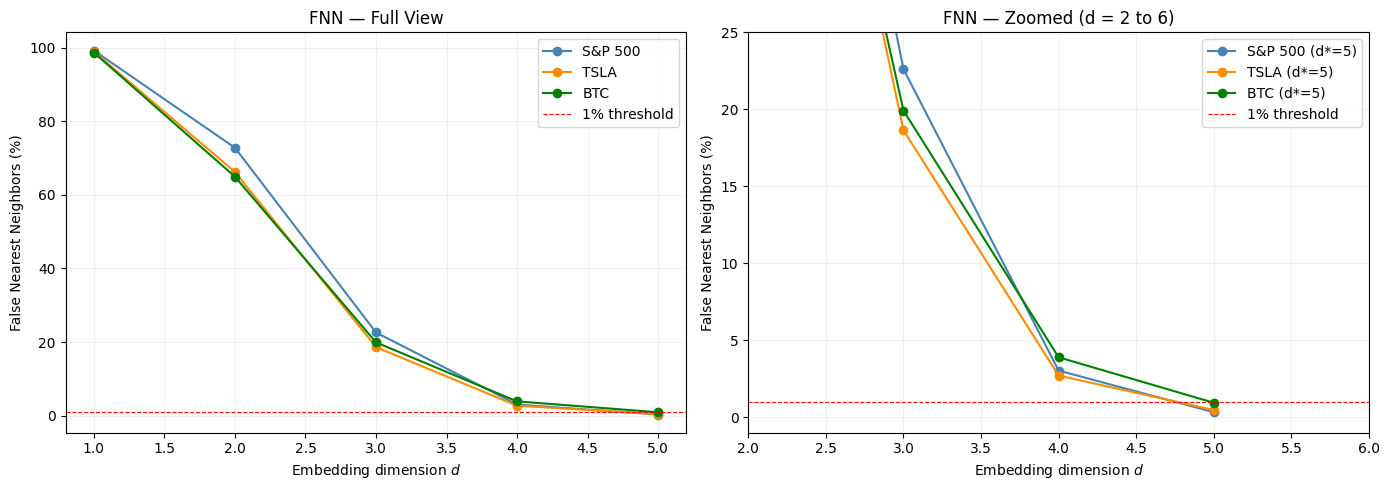

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')

sp500_dims = range(1, len(fnn_sp500) + 1)
tsla_dims = range(1, len(fnn_tsla) + 1)
btc_dims = range(1, len(fnn_btc) + 1)

# Full view
axes[0].plot(sp500_dims, fnn_sp500, 'o-', color='steelblue', label='S&P 500')
axes[0].plot(tsla_dims, fnn_tsla, 'o-', color='darkorange', label='TSLA')
axes[0].plot(btc_dims, fnn_btc, 'o-', color='green', label='BTC')
axes[0].axhline(y=1, color='red', linestyle='--', linewidth=0.8, label='1% threshold')
axes[0].set_xlabel('Embedding dimension $d$')
axes[0].set_ylabel('False Nearest Neighbors (%)')
axes[0].set_title('FNN — Full View')
axes[0].set_facecolor('white')
axes[0].legend()
axes[0].grid(alpha=0.3, color='lightgrey')

# Zoomed view
axes[1].plot(sp500_dims, fnn_sp500, 'o-', color='steelblue', label=f'S&P 500 (d*={d_sp500})')
axes[1].plot(tsla_dims, fnn_tsla, 'o-', color='darkorange', label=f'TSLA (d*={d_tsla})')
axes[1].plot(btc_dims, fnn_btc, 'o-', color='green', label=f'BTC (d*={d_btc})')
axes[1].axhline(y=1, color='red', linestyle='--', linewidth=0.8, label='1% threshold')
axes[1].set_xlim(2, 6)
axes[1].set_ylim(-1, 25)
axes[1].set_xlabel('Embedding dimension $d$')
axes[1].set_ylabel('False Nearest Neighbors (%)')
axes[1].set_title('FNN — Zoomed (d = 2 to 6)')
axes[1].set_facecolor('white')
axes[1].legend()
axes[1].grid(alpha=0.3, color='lightgrey')

plt.tight_layout()
plt.show()

## Takens Embedding

With optimal $d = 5$ established for all three assets, we now construct the sliding window embedding:

$$\mathbf{x}_t = (r_t, r_{t-1}, r_{t-2}, r_{t-3}, r_{t-4}) \in \mathbb{R}^5$$

Each consecutive window of 5 returns becomes one point in $\mathbb{R}^5$ — converting the 1D return series into a point cloud ready for TDA.

In [5]:
def takens_embedding(series, d):
    """
    Compute the Takens delay embedding of a time series.
    
    Parameters
    ----------
    series : np.ndarray
        1D time series
    d : int
        Embedding dimension
    
    Returns
    -------
    X : np.ndarray, shape (n - d + 1, d)
        Point cloud in R^d
    """
    n = len(series)
    return np.array([series[i:i+d] for i in range(n - d + 1)])

# Apply to all three assets
X_sp500 = takens_embedding(sp500.values, d_sp500)
X_tsla = takens_embedding(tsla.values, d_tsla)
X_btc = takens_embedding(btc.values, d_btc)

print(f"S&P 500 point cloud: {X_sp500.shape}")
print(f"TSLA point cloud:    {X_tsla.shape}")
print(f"BTC point cloud:     {X_btc.shape}")

S&P 500 point cloud: (6032, 5)
TSLA point cloud:    (3395, 5)
BTC point cloud:     (3388, 5)


## PCA Visualization of Takens Embedding

PCA projects the 5-dimensional point clouds onto their two most informative directions for visualization.

All three assets form a **single dense cluster** centered at the origin — consistent with normalized returns having zero mean and unit variance. No clear geometric structure (loops, voids) is visible in the 2D projection.

Notable difference: **TSLA is more spread out** than S&P 500 and BTC — reflecting its higher volatility and more complex return dynamics even after normalization.

The absence of visible structure in 2D does not mean there is no topology — persistent homology operates in the full $\mathbb{R}^5$ space where structure may exist at scales invisible to PCA projection.

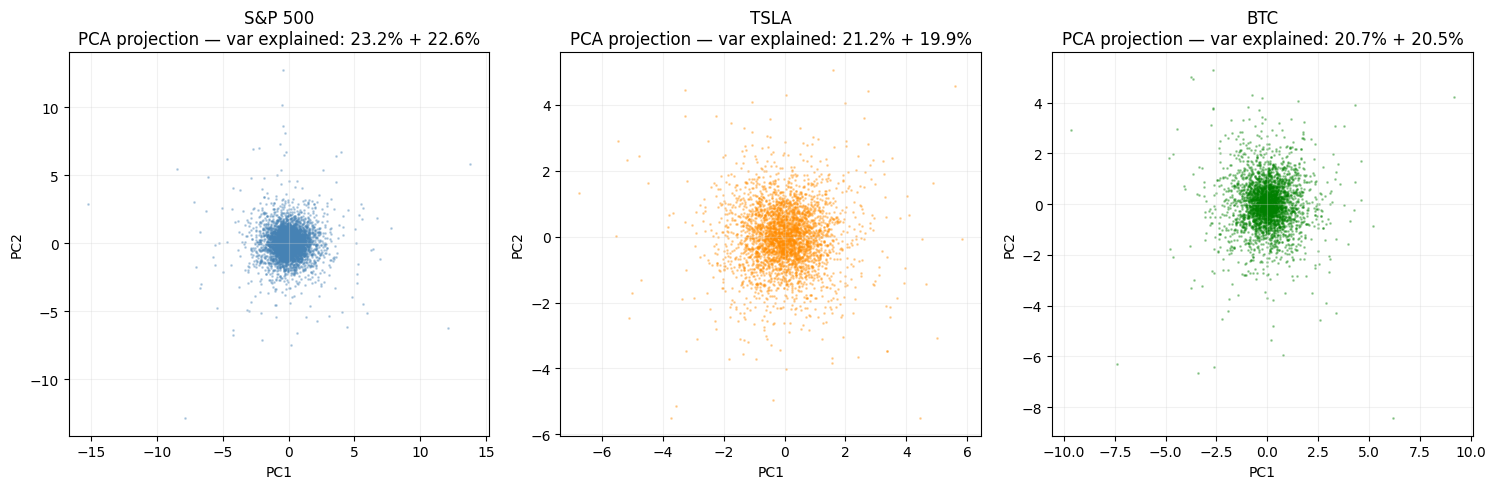

In [6]:
from sklearn.decomposition import PCA

fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor='white')

assets = [
    (X_sp500, 'S&P 500', 'steelblue'),
    (X_tsla, 'TSLA', 'darkorange'),
    (X_btc, 'BTC', 'green')
]

for ax, (X, title, color) in zip(axes, assets):
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    variance = pca.explained_variance_ratio_
    
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=color, s=1, alpha=0.3)
    ax.set_title(f'{title}\nPCA projection — var explained: {variance[0]:.1%} + {variance[1]:.1%}')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_facecolor('white')
    ax.grid(alpha=0.3, color='lightgrey')

plt.tight_layout()
plt.show()

## Conclusions

The Takens embedding pipeline is complete:

| Asset | Days | Optimal $d$ (FNN) | Point Cloud Shape |
|-------|------|-------------------|-------------------|
| S&P 500 | 6036 | 5 | (6032, 5) |
| TSLA | 3399 | 5 | (3395, 5) |
| BTC | 3392 | 5 | (3388, 5) |

Key findings:
- **FNN converges at $d = 5$** for all three assets — suggesting a common low-dimensional structure in normalized financial returns
- **TSLA shows higher spread** in the PCA projection — consistent with its higher volatility

Next: Notebook 04 — Visibility Graphs as an alternative pipeline to Takens embedding.